In [1]:
import gzip
import json
import math
import re
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE = Path("/Users/jayasanka/Documents/FitWise AI")
META_PATH = BASE / "meta_Amazon_Fashion.jsonl.gz"
REVIEW_PATH = BASE / "Amazon_Fashion.jsonl.gz"

USD_TO_INR = 83
SAMPLE_SIZE = 10_000   # start with 10k; increase later

In [2]:
def read_jsonl_gz(path, n=None):
    rows = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if n is not None and i >= n:
                break
            rows.append(json.loads(line))
    return rows

In [3]:
sample_meta = read_jsonl_gz(META_PATH, n=1)[0]
sample_review = read_jsonl_gz(REVIEW_PATH, n=1)[0]

print("META keys:", list(sample_meta.keys()))
print("REVIEW keys:", list(sample_review.keys()))
print("\nMeta title:", sample_meta["title"])
print("Review rating:", sample_review["rating"])
print("Join key (both): parent_asin")

META keys: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']
REVIEW keys: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Meta title: YUEDGE 5 Pairs Men's Moisture Control Cushioned Dry Fit Casual Athletic Crew Socks for Men (Blue, Size 9-12)
Review rating: 5.0
Join key (both): parent_asin


In [4]:
meta_rows = read_jsonl_gz(META_PATH, n=SAMPLE_SIZE)
df = pd.DataFrame(meta_rows)

print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,AMAZON FASHION,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GiveGift,[],{'Package Dimensions': '10.31 x 8.5 x 1.73 inc...,B08BHN9PK5,None
1,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"[Drawstring closure, Machine Wash]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,[],{'Package Dimensions': '15 x 10.2 x 0.4 inches...,B08R39MRDW,None
2,AMAZON FASHION,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"[Zipper closure, Hand Wash Only]",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pastel by Vivienne,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B077KJHCJ4,None
3,AMAZON FASHION,Mento Streamtail,2.0,1,"[Thermoplastic Rubber sole, High Density Premi...",[Slip on the Women's Mento and you're ready to...,29.81,[{'thumb': 'https://m.media-amazon.com/images/...,[],Guy Harvey,[],{'Package Dimensions': '11.22 x 4.72 x 4.33 in...,B0811M2JG9,None
4,AMAZON FASHION,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[Pull On closure, Size Guide: ""S"" fits calf 10...",[Ronnox Calf Sleeves - Allowing Your Body to P...,17.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'HONEST Review: RONNOX Women's 3-Pa...,RONNOX,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B07SB2892S,None


In [5]:
df.info()
df[["price", "average_rating", "rating_number"]].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   main_category    10000 non-null  object 
 1   title            10000 non-null  object 
 2   average_rating   10000 non-null  float64
 3   rating_number    10000 non-null  int64  
 4   features         10000 non-null  object 
 5   description      10000 non-null  object 
 6   price            1104 non-null   float64
 7   images           10000 non-null  object 
 8   videos           10000 non-null  object 
 9   store            9668 non-null   object 
 10  categories       10000 non-null  object 
 11  details          10000 non-null  object 
 12  parent_asin      10000 non-null  object 
 13  bought_together  0 non-null      object 
dtypes: float64(2), int64(1), object(11)
memory usage: 1.1+ MB


,price,average_rating,rating_number
count,1104.000000,10000.000000,10000.000000
mean,31.874239,3.923900,61.467600
std,46.342719,0.950459,744.442764
min,0.010000,1.000000,1.000000
25%,11.990000,3.400000,2.000000
50%,19.000000,4.000000,4.500000
75%,33.960000,4.600000,12.000000
max,489.990000,5.000000,36058.000000


In [6]:
CN_MAP = {"女士": "women", "男士": "men", "中性": "unisex"}

def get_department(row):
    details = row.get("details") or {}
    if isinstance(details, dict):
        dept = details.get("Department")
        if dept:
            return str(dept).strip()
    return None

def normalize_department(dept):
    if pd.isna(dept) or dept is None:
        return None
    d = str(dept).lower().strip()
    if d in CN_MAP:
        return CN_MAP[d]
    if d in {"womens", "women", "woman"}:
        return "women"
    if d in {"mens", "men", "man"}:
        return "men"
    if d in {"girls", "girl"}:
        return "girls"
    if d in {"boys", "boy"}:
        return "boys"
    if "unisex" in d or "unnisex" in d:
        return "unisex"
    if "baby" in d and "girl" in d:
        return "baby_girls"
    if "baby" in d and "boy" in d:
        return "baby_boys"
    if "baby" in d:
        return "baby_unisex"
    if "kid" in d or "child" in d:
        return "kids"
    if "jewelry" in d:
        return "jewelry"
    return d

def department_group(dept):
    if pd.isna(dept) or dept is None:
        return "unknown"

    d = str(dept).lower()
    junk = ["earring", "watch", "dress", "shoe", "t-shirt", "#n/a", "helix", "mallory"]
    if any(j in d for j in junk):
        return "unknown"
    if "," in d or "mens-womens" in d:
        return "unisex"

    if re.search(r"\bwomen|\bwoman|\bfeminino", d):
        return "women"
    if re.search(r"\bmen|\bmens\b", d) and "women" not in d:
        return "men"
    if re.search(r"\bgirls?\b", d):
        return "girls"
    if re.search(r"\bboys?\b", d):
        return "boys"
    if "kid" in d or "child" in d or "teen" in d:
        return "kids"
    if "unisex" in d:
        return "unisex"
    if d in {"women", "men", "unisex", "girls", "boys", "kids", "baby_girls", "baby_boys", "baby_unisex", "jewelry"}:
        return d
    return "unknown"

def infer_department_from_title(title):
    t = str(title).lower()
    if re.search(r"\bwomen'?s\b|\bladies\b", t):
        return "women"
    if re.search(r"\bmen'?s\b|\bmen\b", t) and "women" not in t:
        return "men"
    if re.search(r"\bgirls?\b", t):
        return "girls"
    if re.search(r"\bboys?\b", t):
        return "boys"
    return "unknown"

In [7]:
def first_image_url(images):
    if not isinstance(images, list) or not images:
        return None
    img = images[0]
    return img.get("hi_res") or img.get("large") or img.get("thumb")

def flatten_list(value):
    if isinstance(value, list):
        return " | ".join(str(v) for v in value if v)
    return ""

df["department_raw"] = df.apply(get_department, axis=1)
df["department"] = df["department_raw"].apply(normalize_department)
df["department_group"] = df["department"].apply(department_group)

products_df = pd.DataFrame({
    "product_id": df["parent_asin"],
    "title": df["title"],
    "brand": df["store"],
    "department": df["department"],
    "department_group": df["department_group"],
    "department_final": df["department_group"].where(
        df["department_group"] != "unknown",
        df["title"].apply(infer_department_from_title)
    ),
    "price": df["price"],
    "average_rating": df["average_rating"],
    "review_count": df["rating_number"],
    "popularity_score": df.apply(
        lambda r: round(math.log(r["rating_number"] + 1) * r["average_rating"], 4),
        axis=1
    ),
    "features": df["features"].apply(flatten_list),
    "description": df["description"].apply(flatten_list),
    "image_url": df["images"].apply(first_image_url),
    "main_category": df["main_category"],
})

products_df.head()

,product_id,title,brand,department,department_group,department_final,price,average_rating,review_count,popularity_score,features,description,image_url,main_category
0,B08BHN9PK5,YUEDGE 5 Pairs Men's Moisture Control Cushione...,GiveGift,None,unknown,men,NaN,4.6,16,13.0328,,,https://m.media-amazon.com/images/I/81XlFXImFr...,AMAZON FASHION
1,B08R39MRDW,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,DouBCQ,None,unknown,women,NaN,4.1,7,8.5257,Drawstring closure | Machine Wash,,https://m.media-amazon.com/images/I/91Z4G2jlFe...,AMAZON FASHION
2,B077KJHCJ4,Pastel by Vivienne Honey Vanilla Girls' Trapez...,Pastel by Vivienne,None,unknown,girls,NaN,4.3,11,10.6851,Zipper closure | Hand Wash Only,,https://m.media-amazon.com/images/I/612-CtsBAv...,AMAZON FASHION
3,B0811M2JG9,Mento Streamtail,Guy Harvey,women,women,women,29.81,2.0,1,1.3863,Thermoplastic Rubber sole | High Density Premi...,Slip on the Women's Mento and you're ready to ...,https://m.media-amazon.com/images/I/61qmATFO2F...,AMAZON FASHION
4,B07SB2892S,RONNOX Women's 3-Pairs Bright Colored Calf Com...,RONNOX,women,women,women,17.99,4.3,3032,34.4744,"Pull On closure | Size Guide: ""S"" fits calf 10...",Ronnox Calf Sleeves - Allowing Your Body to Pe...,https://m.media-amazon.com/images/I/91ub366PdK...,AMAZON FASHION


In [8]:
print(products_df.isna().mean().sort_values(ascending=False).head())
print("\nDepartment final:")
print(products_df["department_final"].value_counts().head(10))

price         0.8896
department    0.8072
brand         0.0332
product_id    0.0000
title         0.0000
dtype: float64

Department final:
department_final
unknown       3875
women         3547
men           1153
girls          775
unisex         368
boys           236
baby_girls      22
baby_boys       16
kids             4
jewelry          4
Name: count, dtype: int64


In [9]:
print("Products with price:", products_df["price"].notna().sum(), "/", len(products_df))
print("Products with image:", products_df["image_url"].notna().sum(), "/", len(products_df))

print("\nTop brands:")
print(products_df["brand"].value_counts().head(10))

print("\nTop departments:")
print(products_df["department_final"].value_counts().head(10))

Products with price: 1104 / 10000
Products with image: 10000 / 10000

Top brands:
brand
Nike           57
Verdusa        50
GRACE KARIN    45
SweatyRocks    36
Floerns        35
Disney         35
DOUBLJU        34
Milumia        31
Generic        29
SheIn          29
Name: count, dtype: int64

Top departments:
department_final
unknown       3875
women         3547
men           1153
girls          775
unisex         368
boys           236
baby_girls      22
baby_boys       16
kids             4
jewelry          4
Name: count, dtype: int64


In [1]:
USD_TO_LKR = 300.0   # example; check current USD→LKR rate and change this


In [2]:
import gzip
import json
import math
import re
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE = Path("/Users/jayasanka/Documents/FitWise AI")
META_PATH = BASE / "meta_Amazon_Fashion.jsonl.gz"
REVIEW_PATH = BASE / "Amazon_Fashion.jsonl.gz"

USD_TO_LKR = 300.0   # Amazon prices are USD → convert to LKR here

In [3]:
def first_image_url(images):
    if not isinstance(images, list) or not images:
        return None
    img = images[0]
    return img.get("hi_res") or img.get("large") or img.get("thumb")

def flatten_list(value):
    if isinstance(value, list):
        return " | ".join(str(v) for v in value if v)
    return ""

CN_MAP = {"女士": "women", "男士": "men", "中性": "unisex"}

def get_department(row):
    details = row.get("details") or {}
    if isinstance(details, dict):
        dept = details.get("Department")
        if dept:
            return str(dept).strip()
    return None

def normalize_department(dept):
    if pd.isna(dept) or dept is None:
        return None
    d = str(dept).lower().strip()
    if d in CN_MAP:
        return CN_MAP[d]
    if d in {"womens", "women", "woman"}:
        return "women"
    if d in {"mens", "men", "man"}:
        return "men"
    if "unisex" in d:
        return "unisex"
    if re.search(r"\bgirls?\b", d):
        return "girls"
    if re.search(r"\bboys?\b", d):
        return "boys"
    return d

def infer_department_from_title(title):
    t = str(title).lower()
    if re.search(r"\bwomen'?s\b|\bladies\b", t):
        return "women"
    if re.search(r"\bmen'?s\b|\bmen\b", t) and "women" not in t:
        return "men"
    if re.search(r"\bgirls?\b", t):
        return "girls"
    if re.search(r"\bboys?\b", t):
        return "boys"
    return "unknown"

def usd_to_lkr(usd):
    return round(float(usd) * USD_TO_LKR, 2)

In [4]:
def read_jsonl_gz(path, n=None):
    rows = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if n is not None and i >= n:
                break
            rows.append(json.loads(line))
    return rows

sample_meta = read_jsonl_gz(META_PATH, n=1)[0]
sample_review = read_jsonl_gz(REVIEW_PATH, n=1)[0]

print("META keys:", list(sample_meta.keys()))
print("REVIEW keys:", list(sample_review.keys()))
print("Join key: parent_asin → product_id")
print("Amazon price is USD:", sample_meta.get("price"))
if sample_meta.get("price"):
    print("Same price in LKR:", usd_to_lkr(sample_meta["price"]))

META keys: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']
REVIEW keys: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Join key: parent_asin → product_id
Amazon price is USD: None


In [5]:
def load_priced_meta(path):
    rows = []
    scanned = 0

    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            scanned += 1
            row = json.loads(line)

            if row.get("price") is None:
                continue
            if not row.get("parent_asin") or not row.get("title"):
                continue

            rows.append(row)

    print(f"Scanned {scanned:,} meta lines")
    print(f"Loaded {len(rows):,} priced products")
    return pd.DataFrame(rows)

df = load_priced_meta(META_PATH)
print("Shape:", df.shape)
df.head()

Scanned 826,108 meta lines
Loaded 50,244 priced products
Shape: (50244, 14)


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,AMAZON FASHION,Mento Streamtail,2.0,1,"[Thermoplastic Rubber sole, High Density Premi...",[Slip on the Women's Mento and you're ready to...,29.81,[{'thumb': 'https://m.media-amazon.com/images/...,[],Guy Harvey,[],{'Package Dimensions': '11.22 x 4.72 x 4.33 in...,B0811M2JG9,None
1,AMAZON FASHION,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"[Pull On closure, Size Guide: ""S"" fits calf 10...",[Ronnox Calf Sleeves - Allowing Your Body to P...,17.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'HONEST Review: RONNOX Women's 3-Pa...,RONNOX,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B07SB2892S,None
2,AMAZON FASHION,LYCKYY Women's Tie Dye Sweatshirt Crewneck Lon...,3.7,52,[Pull On closure],[Tie dye shirts for Women long sleeve crewneck...,9.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],LYCKYY,[],"{'Department': 'womens', 'Date First Available...",B08FMLXY1Z,None
3,AMAZON FASHION,Sexyshine Women's Casual Fall Knit Long Sleeve...,3.6,7,"[Cotton Blend, Asian Size,Smaller than US Size...",[Sexyshine Women's Casual Fall Knit Long Sleev...,26.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Sexyshine,[],"{'Is Discontinued By Manufacturer': 'No', 'Pro...",B07G854X4J,None
4,AMAZON FASHION,Result Core Men's Soft Shell II Gilet Red 3XL,5.0,1,"[Polyester,Microfleece,Elastane]",[],53.95,[{'thumb': 'https://m.media-amazon.com/images/...,[],Result Core,[],"{'Is Discontinued By Manufacturer': 'No', 'Ite...",B009E2O6KA,None


In [6]:
df["department"] = df.apply(get_department, axis=1).apply(normalize_department)
df["department_final"] = df["department"].where(
    df["department"].notna(),
    df["title"].apply(infer_department_from_title)
)

products_df = pd.DataFrame({
    "product_id": df["parent_asin"],
    "title": df["title"],
    "brand": df["store"],
    "department": df["department"],
    "department_final": df["department_final"],
    "price_usd": df["price"],                          # original Amazon USD
    "price": df["price"].apply(usd_to_lkr),             # main price in LKR
    "average_rating": df["average_rating"],
    "review_count": df["rating_number"],
    "popularity_score": df.apply(
        lambda r: round(math.log(r["rating_number"] + 1) * r["average_rating"], 4),
        axis=1
    ),
    "features": df["features"].apply(flatten_list),
    "description": df["description"].apply(flatten_list),
    "image_url": df["images"].apply(first_image_url),
    "main_category": df["main_category"],
})

assert products_df["price"].notna().all()

print("products_df:", products_df.shape)
print("Price LKR:", products_df["price"].min(), "–", products_df["price"].max())
products_df[["title", "price_usd", "price", "average_rating"]].head()

products_df: (50244, 14)
Price LKR: 3.0 – 3900000.0


,title,price_usd,price,average_rating
0,Mento Streamtail,29.81,8943.0,2.0
1,RONNOX Women's 3-Pairs Bright Colored Calf Com...,17.99,5397.0,4.3
2,LYCKYY Women's Tie Dye Sweatshirt Crewneck Lon...,9.99,2997.0,3.7
3,Sexyshine Women's Casual Fall Knit Long Sleeve...,26.99,8097.0,3.6
4,Result Core Men's Soft Shell II Gilet Red 3XL,53.95,16185.0,5.0


In [7]:
print(products_df.columns.tolist())


['product_id', 'title', 'brand', 'department', 'department_final', 'price_usd', 'price', 'average_rating', 'review_count', 'popularity_score', 'features', 'description', 'image_url', 'main_category']


In [8]:
product_ids = set(products_df["product_id"])
print(f"Syncing reviews for {len(product_ids):,} products...")

review_rows = []
lines_scanned = 0

with gzip.open(REVIEW_PATH, "rt", encoding="utf-8") as f:
    for line in f:
        lines_scanned += 1
        if lines_scanned % 500_000 == 0:
            print(f"  ... {lines_scanned:,} lines, {len(review_rows):,} reviews")

        r = json.loads(line)
        pid = r.get("parent_asin")
        if pid not in product_ids:
            continue

        ts = r.get("timestamp")
        review_time = datetime.fromtimestamp(ts / 1000, tz=timezone.utc) if ts else None

        review_rows.append({
            "product_id": pid,
            "rating": r.get("rating"),
            "review_title": r.get("title"),
            "review_text": r.get("text"),
            "helpful_vote": r.get("helpful_vote", 0),
            "verified_purchase": r.get("verified_purchase"),
            "review_time": review_time,
            "user_id": r.get("user_id"),
        })

reviews_df = pd.DataFrame(review_rows)

print(f"Reviews loaded: {len(reviews_df):,}")
print(f"Products with reviews: {reviews_df['product_id'].nunique():,}")
reviews_df.head()

Syncing reviews for 50,244 products...
  ... 500,000 lines, 81,605 reviews
  ... 1,000,000 lines, 162,604 reviews
  ... 1,500,000 lines, 244,627 reviews
  ... 2,000,000 lines, 333,005 reviews
  ... 2,500,000 lines, 433,560 reviews
Reviews loaded: 433,735
Products with reviews: 50,238


,product_id,rating,review_title,review_text,helpful_vote,verified_purchase,review_time,user_id
0,B00LOPVX74,5.0,Pretty locket,I think this locket is really pretty. The insi...,3,True,2020-01-09 00:06:34.489000+00:00,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ
1,B07B4JXK8D,5.0,A,Great,0,True,2020-12-20 01:04:06.701000+00:00,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ
2,B00XESJTDE,5.0,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,0,True,2015-08-13 14:29:26+00:00,AHSPLDNW5OOUK2PLH7GXLACFBZNQ
3,B0BQJ61TXB,5.0,Probably the cutest earrings I have ever owned!,OMG these starfish earring are absolutely the ...,0,False,2023-01-27 22:13:03.365000+00:00,AFSKPY37N3C43SOI5IEXEK5JSIYA
4,B095CHR38Z,2.0,open shoulder t shirt,"I am 5'7"".. usually wear a 14/16 or 0x/1x.. 38...",2,True,2022-02-17 01:41:15.013000+00:00,AFZUK3MTBIBEDQOPAK3OATUOUKLA


In [10]:
orphans = reviews_df[~reviews_df["product_id"].isin(products_df["product_id"])]
print("Orphan reviews:", len(orphans))

merged = reviews_df.merge(products_df, on="product_id", how="inner")
print("Merged rows:", len(merged))
merged[["title", "price", "rating", "review_text"]].head(10)

Orphan reviews: 0
Merged rows: 433735


,title,price,rating,review_text
0,CHUVORA 925 Sterling Silver Open Celtic Knot C...,9000.0,5.0,I think this locket is really pretty. The insi...
1,XX-Large Slip Stop Single Tread Slipper Socks ...,6297.0,5.0,Great
2,SA106 Womens Rhinestone Jewel Polarized Lens 6...,3885.0,5.0,I LOVE these glasses! They fit perfectly over...
3,"BAMOWEY African Woman Leather Earrings,Black A...",2397.0,5.0,OMG these starfish earring are absolutely the ...
4,Womens Short Sleeve V Neck Shirts Loose Tops B...,3297.0,2.0,"I am 5'7"".. usually wear a 14/16 or 0x/1x.. 38..."
5,Needzo Ghost and Pumpkin Orange Sequins Witch ...,3564.0,5.0,Purchased for my sister to use on Halloween......
6,AVOD Nylon Watch Bands Compatible with Fitbit ...,4197.0,5.0,I just had to replace my old Fitbit 3 to the c...
7,Nike Women's Dri-Fit Training Hoodie (Plus Siz...,16497.0,1.0,The photo doesn't show this but you need a col...
8,"Rocks for Painting, Painting Rocks, Perfect Fo...",3591.0,5.0,I purchased these for an art project with my 5...
9,Trendy Turquoise Clip On Earrings for Women - ...,7797.0,3.0,I was expecting a bit more these... they are j...


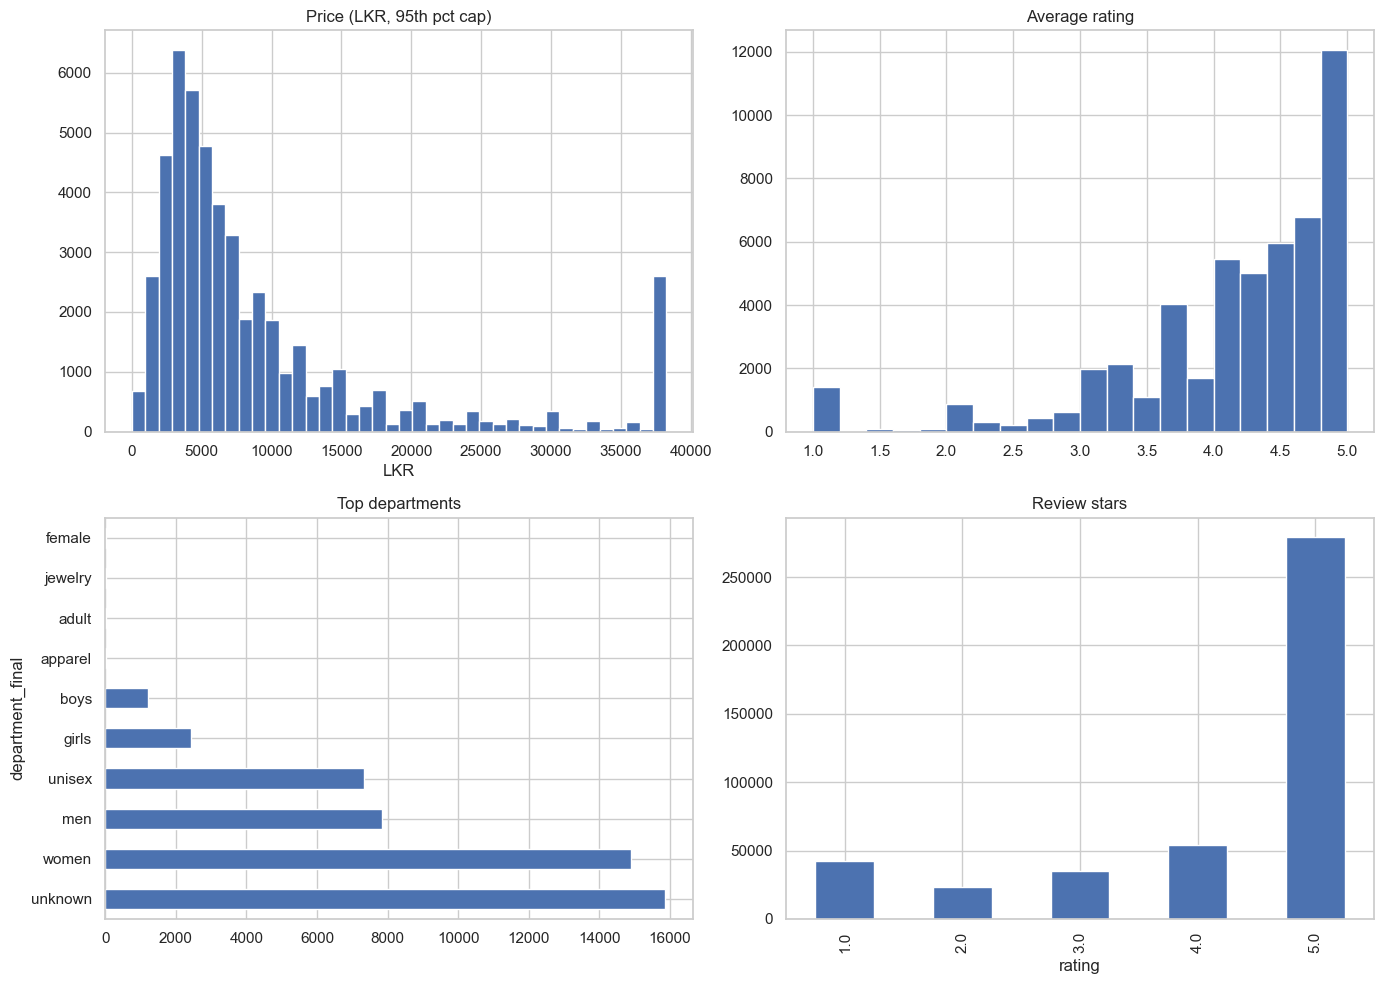

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

products_df["price"].clip(upper=products_df["price"].quantile(0.95)).hist(bins=40, ax=axes[0, 0])
axes[0, 0].set_title("Price (LKR, 95th pct cap)")
axes[0, 0].set_xlabel("LKR")

products_df["average_rating"].hist(bins=20, ax=axes[0, 1])
axes[0, 1].set_title("Average rating")

products_df["department_final"].value_counts().head(10).plot(kind="barh", ax=axes[1, 0])
axes[1, 0].set_title("Top departments")

reviews_df["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Review stars")

plt.tight_layout()
plt.show()

In [12]:
out_dir = BASE / "data" / "full"
out_dir.mkdir(parents=True, exist_ok=True)

products_df.to_csv(out_dir / "products_priced_full.csv", index=False)
reviews_df.to_csv(out_dir / "reviews_priced_full.csv", index=False)

print("Saved with prices in LKR (column: price)")
print(f"  products: {len(products_df):,} rows")
print(f"  reviews:  {len(reviews_df):,} rows")
print(f"  rate used: 1 USD = {USD_TO_LKR} LKR")

Saved with prices in LKR (column: price)
  products: 50,244 rows
  reviews:  433,735 rows
  rate used: 1 USD = 300.0 LKR
